# Add imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate random input data to train on

In [11]:
observations = 10000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs = np.column_stack((xs, zs))
print(f"shape of array {inputs.shape}")

shape of array (10000, 2)


# Create a target we will aim at
## f(x,z) = 2*x - 3*z + 5 + noise
### 2*x ---> w1
### 3*z ---> w2
### 5   ---> b

In [12]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
print(targets.shape)

(10000, 1)


# Plot training data

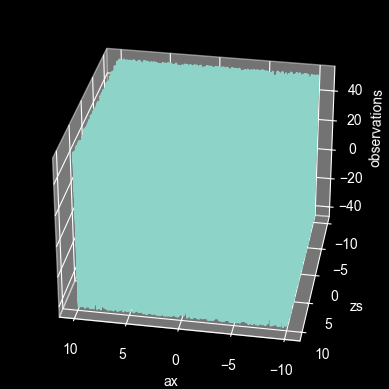

In [13]:
targets = targets.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel("ax")
ax.set_ylabel("zs")
ax.set_zlabel("observations")
ax.view_init(azim=100)
plt.show()
targets = targets.reshape(observations, 1)


# initialize variables

In [14]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2, 1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights)
print(biases)

[[-0.03309077]
 [ 0.09214432]]
[-0.00299889]


# Learning rate

In [15]:
learning_rate = 0.02

# Train the model

In [16]:
for i in range(100):
    outputs = np.dot(inputs, weights) + biases
    deltas = outputs - targets
    loss = np.sum(deltas ** 2 ) / 2 / observations
    print(loss)
    deltas_scaled = deltas / observations
    weights = weights -  learning_rate * np.dot(inputs.T, deltas_scaled)
    biases = biases - learning_rate * np.sum(deltas_scaled)


239.14512433497543
38.06739656711822
14.649612837766222
11.569134021427125
10.83085054617983
10.375772377971947
9.967767980363913
9.579244147306296
9.206486084674523
8.848532739786553
8.504759321995854
8.174599898745411
7.857514851656192
7.552986377818574
7.260517230411724
6.979629859432219
6.7098656265226335
6.450784055478059
6.201962112957185
5.9629935177372575
5.733488077329412
5.513071050864807
5.301382537210571
5.098076887316345
4.902822139831907
4.715299479074339
4.535202714459685
4.362237780549125
4.196122256893289
4.036584906890769
3.8833652349077927
3.7362130609359956
3.59488811209371
3.45915963030381
3.3288059955075275
3.203614363798971
3.0833803198895313
2.9679075433347015
2.8570074879782936
2.7504990740906736
2.6482083926983213
2.5499684216219327
2.455618752759418
2.365005330168479
2.2779801985211328
2.1944012615194155
2.1141320498778375
2.0370414984937253
1.9630037324416145
1.891897861442269
1.8236077824707222
1.7580219901810408
1.695033394838258
1.6345391474602182
1.57644

# Print weight and bias

In [17]:
print(weights, biases)

[[ 2.00053979]
 [-2.99839294]] [4.33215425]


# Plot last outputs and targets


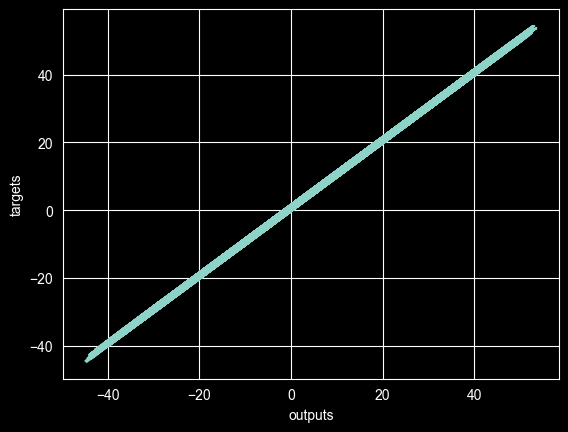

In [18]:
plt.plot(outputs, targets)
plt.xlabel("outputs")
plt.ylabel("targets")
plt.show()